In [44]:
# -*- coding: utf-8 -*-
"""
Created on Thu Jan  2 15:50:57 2025

@author: Pau
"""
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Latex

Distretization

In [45]:
T = 300 #days
n = 7200 #2400 hours in 100 days
dt = T/n #T/n
t = np.zeros(n+1)

Input

In [46]:
C_air_cs = np.zeros(n+1)
C_air_i = np.zeros(n+1)
C_air_generic = np.zeros(n+1)
# source term : 

# from the study of the Source term (see report 3.3)
# Cs - 137 : 8.33*10^7 GBq  
# I - 131 : 1.51*10^9 GBq  
A_Cs_released = 8.33*10**16 #(Bq)
A_I_released = 1.51*10**18 #(Bq)

# some constants
T_Cs = 30.08*365.25*24*3600
T_I = 8.02*24*3600
M_cs = 137
M_i = 131
N_Av = 6.022 * (10**23)

# We convert the activity released into a mass, to use the generic data of Hysplit

mass_cs_released = A_Cs_released * T_Cs / np.log(2) / N_Av * M_cs / 1000 # kg released
mass_i_released = A_I_released * T_I/ np.log(2) / N_Av * M_i / 1000 #kg released

# at the studied point :
C_air_generic[:12] = [10**(-7), 10**(-6), 10**(-5), 10**(-5), 10**(-5), 10**(-5), 10**(-5), 10**(-5), 10**(-5), 10**(-6), 10**(-7), 0] # Generic concentratiion, based on 1 kg released, in mg/m3
C_air_cs_mass = C_air_generic*mass_cs_released #mg/m3
C_air_i_mass = C_air_generic*mass_i_released #mg/m3

#Finally we obtain our initial conditions for both isotopes

C_air_cs = C_air_cs_mass / 1000 / M_cs * N_Av * np.log(2) / T_Cs #in Bq / m3
C_air_i =  C_air_i_mass / 1000 / M_i * N_Av * np.log(2) / T_I #in Bq / m3



Parameters

In [47]:
#---------------- Field type repartition ------------#

a = 0.50 #ordinary field
b = 0.10 #rice
c = 0.40 #pasture

#------------------- TO COMPUTE kre------------------#

RF_agri = 10**(-5) #=RFv_
RF_rice = 0 
RF_pasture = np.zeros(n+1) 
kre = np.zeros(n+1) #averaged over the 3 types of field

#----------------TO COMPUTE Bf & kup------------------#

CR = 0.04 #FOR CESIUM
CR_i = 0.02 #FOR IODINE
ro_r = (a+c) * 1180 + b * 1040
L_r = a * 0.25 + b*0.25 + c*0.15 # roots of the plants
k_g = 0.12
B_max = a*2+b*1.32+c*0.49 # maximum potential biomass = above the ground
B_0 = (a+b)*0.015+c*0.07 # given initial biomass
Bf = np.zeros(n+1)
derivative_Bf = np.zeros(n+1)
kup = np.zeros(n+1)

#-------------------TO COMPUTE kl---------------------#

f_c = 10**3 #L/m^3
f_p = a*1+b*0.8+c*1 #paper page 4
Precipitation= 0.00005 #m/d
Irrigation = a*0.0036 + b*0.0049 + c*0.0022 #m/d
Evaporation = 0.0032 #m/d
R_p = f_p*Precipitation+Irrigation-Evaporation
teta= (a+c)*270+b*600
M_d=1000 #FOR CESIUM
M_d_i = 90 #FOR IODINE
kl =f_c*R_p/(teta*L_r*(1+ro_r*M_d/teta))
kl_i = f_c*R_p/(teta*L_r*(1+ro_r*M_d_i/teta))

#-------------------Other global parameters------------------#


kw = 2.77E-02
kpc = 1.98E-02
ktr = 5.5E-03 #FOR CESIUM
ktr_i = 8.5E-03 #FOR IODINE
kad = 1.9E-03 # For Cs but no value for I
kds = 2.1E-04 # For Cs but no value for I
lambda_g = 3.47E-02
lambda_d = np.log(2)/(30.1*365) #FOR CESIUEM
lambda_d_i = np.log(2)/(8.02)
alpha= a*0.3 + (b+c)*3
Be = a*0.2 + b*0.44 + c*0.49 
f=np.zeros(n+1)
vd_cs = 0.0007 * 3600 * 24 # FOR CESIUM
vd_i = 0.0045 * 3600 * 24 #FOR IODINE

#------------------- Animal products parameters -------------#
a1_milk_cs = 0.8
a2_milk_cs = 0.2
a1_meat_cs = 1

a1_milk_iode = 1
a1_meat_iode = 1

lambda_b1_milk_cs = np.log(2)/1.5
lambda_b2_milk_cs = np.log(2)/15
lambda_b1_meat_cs = np.log(2)/30
lambda_b1_milk_iode = np.log(2)/0.7
lambda_b1_meat_iode = np.log(2)/100

FV_milk = 16.1 #dry-kg / d
FV_meat = 7.2 #dry-kg / d

TF_milk = 0.01 #d/L
TF_meat = 0.05 #d/kg

FS_milk = 0.5 #dry-kg / d
FS_meat = 0.01 #dry-kg / d

rho_s = 1.18 * 10**3 #dry-kg / m^3
Ls = 0.01 #m

CONCENTRATIONS FOR CESIUM

In [48]:
#Initial conditions
X1_cs = np.zeros(n+1) #Concentration at the plant surface (Bq/dry-kg)
X2_cs = np.zeros(n+1) #Concentration in inner tissues (Bq/dry-kg)
X3_cs = np.zeros(n+1) #Concentration at the surface soil (Bq/dry-m²)
X4_cs = np.zeros(n+1) #Concentration in the root zone (Bq/dry-m²)
X5_cs = np.zeros(n+1) #Concentration in the fix soil (Bq/dry-m²)
X6_cs = np.zeros(n+1) #Concentration in the deep soil (Bq/dry-m²)

C_milk_cs = np.zeros(n+1)
C_meat_cs = np.zeros(n+1)


X1_cs[0] = 0 
X2_cs[0] = 0
X3_cs[0] = 0 
X4_cs[0] = 0
X5_cs[0] = 0
X6_cs[0] = 0

C_milk_cs[0] = 0
C_meat_cs[0] = 0

#Euler method
for i in range(n):
    RF_pasture[i] = 10**(-6) * np.exp(-0.01*i*dt) + 10**(-9)
    kre[i] = vd_cs * (a*RF_agri + b*RF_rice + c*RF_pasture[i])

    Bf[i] = B_max * B_0 / ((B_max - B_0)*np.exp(-k_g*i*dt)+ B_0)
    derivative_Bf[i]=(B_max*B_0)*1/((B_max-B_0)*np.exp(-k_g*i*dt)+B_0)**2**(B_max-B_0)*k_g*np.exp(-k_g*i*dt)
    kup[i]=derivative_Bf[i]*CR/(ro_r*L_r)
    f[i]=1-np.exp(-alpha*Bf[i])

    X1_cs[i+1] = (-(kw + lambda_g + ktr + lambda_d)*X1_cs[i] + kre[i]*f[i]/Bf[i]*X3_cs[i] + (vd_cs*f[i]/Bf[i])*C_air_cs[i])*dt + X1_cs[i] #Plant surface compartment
    X2_cs[i+1] = (-(lambda_g + lambda_d)*X2_cs[i] + kup[i]/Be*X4_cs[i] + ktr*Bf[i]/Be*X1_cs[i])*dt + X2_cs[i] #Inner tissues
    X3_cs[i+1] = (-(kpc + kre[i]*f[i] + lambda_d)*X3_cs[i] + kw*Bf[i]*X1_cs[i]+ vd_cs*(1-f[i])*C_air_cs[i])*dt + X3_cs[i] #Surface soil
    X4_cs[i+1] = (-(kl + kup[i] + kad + lambda_d)*X4_cs[i] + kpc*X3_cs[i] + kds*X5_cs[i])*dt + X4_cs[i] #Root zone
    X5_cs[i+1] = (-(kds + lambda_d)*X5_cs[i] + kad*X4_cs[i])*dt + X5_cs[i] #Fix soil
    X6_cs[i+1] = (-(lambda_d)*X6_cs[i] + kl*X4_cs[i])*dt + X6_cs[i] #Deep soil

    C_milk_cs[i+1] = C_milk_cs[i] * (a1_milk_cs*np.exp(-(lambda_b1_milk_cs + lambda_d)*dt) + a2_milk_cs*np.exp(-(lambda_b2_milk_cs + lambda_d)*dt)) + TF_milk * (X1_cs[i+1] + X2_cs[i+1] * FV_milk + X3_cs[i+1]*FS_milk/rho_s/Ls)
    C_meat_cs[i+1] = C_meat_cs[i] * a1_meat_cs*np.exp(-(lambda_b1_meat_cs + lambda_d)*dt) + TF_meat * (X1_cs[i+1] + X2_cs[i+1] * FV_meat + X3_cs[i+1]*FS_meat/rho_s/Ls)





    t[i+1] = t[i] + dt #Time

Plots

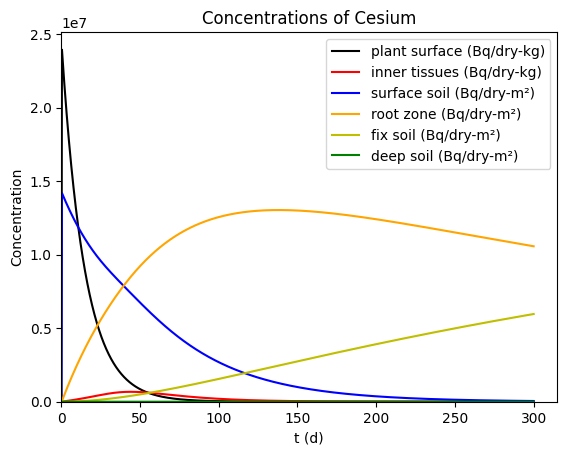

13034086.974027602


In [74]:
#Plot
plt.plot(t, X1_cs, color='black', label = 'plant surface (Bq/dry-kg)')
plt.plot(t, X2_cs, color='r', label = 'inner tissues (Bq/dry-kg)')
plt.plot(t, X3_cs, color='blue', label = 'surface soil (Bq/dry-m²)')
plt.plot(t, X4_cs, color='orange', label = 'root zone (Bq/dry-m²)')
plt.plot(t, X5_cs, color='y', label = 'fix soil (Bq/dry-m²)')
plt.plot(t, X6_cs, color='g', label = 'deep soil (Bq/dry-m²)')
plt.title('Concentrations of Cesium')
plt.xlabel('t (d)')
plt.xlim(left=0)
plt.ylim(bottom = 0)
plt.ylabel('Concentration')
plt.legend(loc = 'upper right')
plt.show()

print(max(X4_cs))

CONCENTRATIONS FOR IODINE

In [50]:
#Initial conditions
X1_i = np.zeros(n+1) #Concentration at the plant surface (Bq/dry-kg)
X2_i = np.zeros(n+1) #Concentration in inner tissues (Bq/dry-kg)
X3_i = np.zeros(n+1) #Concentration at the surface soil (Bq/dry-m²)
X4_i = np.zeros(n+1) #Concentration in the root zone (Bq/dry-m²)
X5_i = np.zeros(n+1) #Concentration in the fix soil (Bq/dry-m²)
X6_i = np.zeros(n+1) #Concentration in the deep soil (Bq/dry-m²)

C_milk_iode = np.zeros(n+1)
C_meat_iode = np.zeros(n+1)



X1_i[0] = 0 
X2_i[0] = 0
X3_i[0] = 0 
X4_i[0] = 0
X5_i[0] = 0
X6_i[0] = 0

C_milk_iode[0] = 0
C_meat_iode[0] = 0


#Euler method
for i in range(n):
    RF_pasture[i] = 10**(-6) * np.exp(-0.01*i*dt) + 10**(-9)
    kre[i] = vd_i * (a*RF_agri + b*RF_rice + c*RF_pasture[i])

    Bf[i] = B_max * B_0 / ((B_max - B_0)*np.exp(-k_g*i*dt)+ B_0)
    derivative_Bf[i]=(B_max*B_0)*1/((B_max-B_0)*np.exp(-k_g*i*dt)+B_0)**2**(B_max-B_0)*k_g*np.exp(-k_g*i*dt)
    kup[i]=derivative_Bf[i]*CR_i/(ro_r*L_r)
    f[i]=1-np.exp(-alpha*Bf[i])

    X1_i[i+1] = (-(kw + lambda_g + ktr_i + lambda_d_i)*X1_i[i] + kre[i]*f[i]/Bf[i]*X3_i[i] + (vd_i*f[i]/Bf[i])*C_air_i[i])*dt + X1_i[i] #Plant surface compartment
    X2_i[i+1] = (-(lambda_g + lambda_d_i)*X2_i[i] + kup[i]/Be*X4_i[i] + ktr_i*Bf[i]/Be*X1_i[i])*dt + X2_i[i] #Inner tissues
    X3_i[i+1] = (-(kpc + kre[i]*f[i] + lambda_d_i)*X3_i[i] + kw*Bf[i]*X1_i[i]+ vd_i*(1-f[i])*C_air_i[i])*dt + X3_i[i] #Surface soil
    X4_i[i+1] = (-(kl_i + kup[i] + lambda_d_i)*X4_i[i] + kpc*X3_i[i])*dt + X4_i[i] #Root zone
    X5_i[i+1] = (-(lambda_d_i)*X5_i[i])*dt + X5_i[i] #Fix soil
    X6_i[i+1] = (-(lambda_d_i)*X6_i[i] + kl_i*X4_i[i])*dt + X6_i[i] #Deep soil

    C_milk_iode[i+1] = C_milk_iode[i] * a1_milk_iode*np.exp(-(lambda_b1_milk_iode + lambda_d)*dt) + TF_milk * (X1_i[i+1] + X2_i[i+1] * FV_milk + X3_i[i+1]*FS_milk/rho_s/Ls)
    C_milk_iode[i+1] = C_meat_iode[i] * a1_meat_iode*np.exp(-(lambda_b1_meat_iode + lambda_d)*dt) + TF_meat * (X1_i[i+1] + X2_i[i+1] * FV_meat + X3_i[i+1]*FS_meat/rho_s/Ls)



    t[i+1] = t[i] + dt #Time

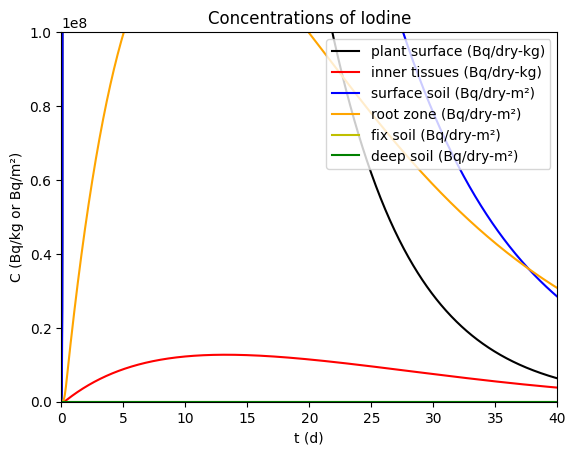

In [78]:
#Plot
plt.plot(t, X1_i, color='black', label = 'plant surface (Bq/dry-kg)')
plt.plot(t, X2_i, color='r', label = 'inner tissues (Bq/dry-kg)')
plt.plot(t, X3_i, color='blue', label = 'surface soil (Bq/dry-m²)')
plt.plot(t, X4_i, color='orange', label = 'root zone (Bq/dry-m²)')
plt.plot(t, X5_i, color='y', label = 'fix soil (Bq/dry-m²)')
plt.plot(t, X6_i, color='g', label = 'deep soil (Bq/dry-m²)')
plt.title('Concentrations of Iodine')
plt.xlabel('t (d)')
plt.xlim(left=0, right=40)
plt.ylim(bottom = 0, top=10**8)
plt.ylabel('C (Bq/kg or Bq/m²)')
plt.legend(loc = 'upper right')
plt.show()



Sum of the 2

In [52]:
X1_sum = X1_cs + X1_i #Concentration at the plant surface (Bq/dry-kg)
X2_sum = X2_cs + X2_i #Concentration in inner tissues (Bq/dry-kg)
X3_sum = X3_cs + X3_i #Concentration at the surface soil (Bq/dry-m²)
X4_sum = X4_cs + X4_i #Concentration in the root zone (Bq/dry-m²)
X5_sum = X5_cs + X5_i #Concentration in the fix soil (Bq/dry-m²)
X6_sum = X6_cs + X6_i #Concentration in the deep soil (Bq/dry-m²)

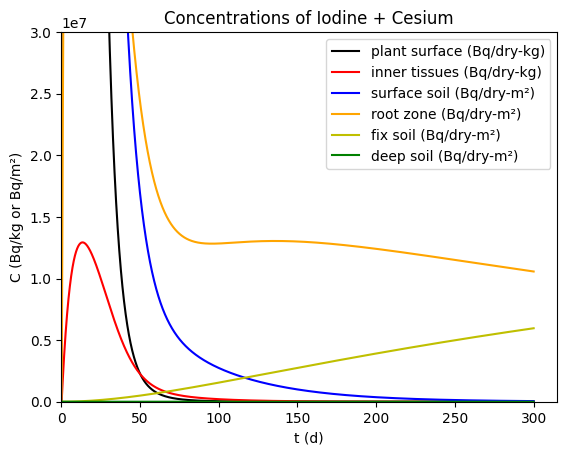

In [73]:
#Plot
plt.plot(t, X1_sum, color='black', label = 'plant surface (Bq/dry-kg)')
plt.plot(t, X2_sum, color='r', label = 'inner tissues (Bq/dry-kg)')
plt.plot(t, X3_sum, color='blue', label = 'surface soil (Bq/dry-m²)')
plt.plot(t, X4_sum, color='orange', label = 'root zone (Bq/dry-m²)')
plt.plot(t, X5_sum, color='y', label = 'fix soil (Bq/dry-m²)')
plt.plot(t, X6_sum, color='g', label = 'deep soil (Bq/dry-m²)')
plt.title('Concentrations of Iodine + Cesium')
plt.xlabel('t (d)')
plt.xlim(left=0)
plt.ylim(bottom = 0, top = 3*10**7)
plt.ylabel('C (Bq/kg or Bq/m²)')
plt.legend(loc = 'upper right')
plt.show()



Concentration in vegetables from harvest

In [86]:
#Since the harvest takes place more than two months after the accident, and the half life of Iodine is of about 8 days,
#we can assume that the iodine in the soil is null at harvest

t_harvest_rice = 69 # 69 days after the release
t_harvest_ordinary = 79 #79 days after the release (apples)

C_sp_t_harvest_rice = 0 #Surface plant (because we wash them)
C_sp_t_harvest_ordinary = X3_sum[t_harvest_ordinary] #Surface plant
C_it_t_harvest_rice = X2_sum[t_harvest_rice] #inner tissues
C_it_t_harvest_ordinary = X2_sum[t_harvest_ordinary] #inner tissues

C_rice_at_harvest = C_it_t_harvest_rice * 1
C_ordinary_at_harvest = C_it_t_harvest_ordinary * 0.14 # no leafy vegetable harvested


C_rice_from_harvest = [C_rice_at_harvest*np.exp(-lambda_d*t) for t in range(70*365)]
C_ordinary_from_harvest = [C_ordinary_at_harvest*np.exp(-lambda_d*t) for t in range(70*365)]

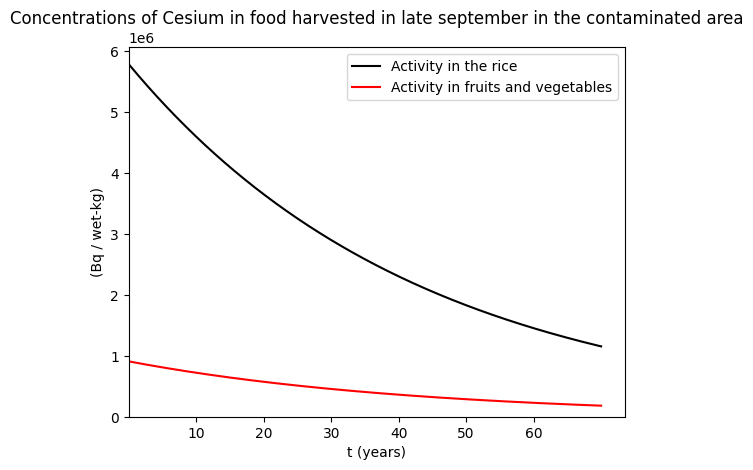

In [88]:
#Plot
plt.plot(C_rice_from_harvest, color='black', label = 'Activity in the rice')
plt.plot(C_ordinary_from_harvest, color='r', label = 'Activity in fruits and vegetables')
plt.title('Concentrations of Cesium in food harvested in late september in the contaminated area')
plt.xlabel('t (years)')
tick_positions = [10*365, 20*365, 30*365, 40*365, 50*365, 60*365]  # 2:00, 6:00, ...
tick_labels = ["10", "20", "30", "40", "50", "60"]
plt.xticks(tick_positions, tick_labels)
plt.xlim(left=0)
plt.ylim(bottom = 0)
plt.ylabel('(Bq / wet-kg)')
plt.legend(loc = 'upper right')
plt.show()


Animal product results

In [56]:
sum_C_milk = C_milk_cs + C_milk_iode
sum_C_meat = C_meat_cs + C_meat_iode

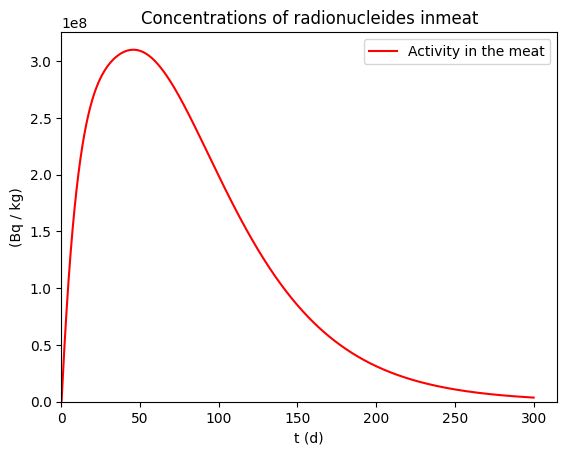

In [90]:
#Plot
plt.plot(t, sum_C_meat, color='r', label = 'Activity in the meat')
plt.title('Concentrations of radionucleides inmeat')
plt.xlabel('t (d)')
plt.xlim(left=0)
plt.ylim(bottom = 0)
plt.ylabel('(Bq / kg)')
plt.legend(loc = 'upper right')
plt.show()

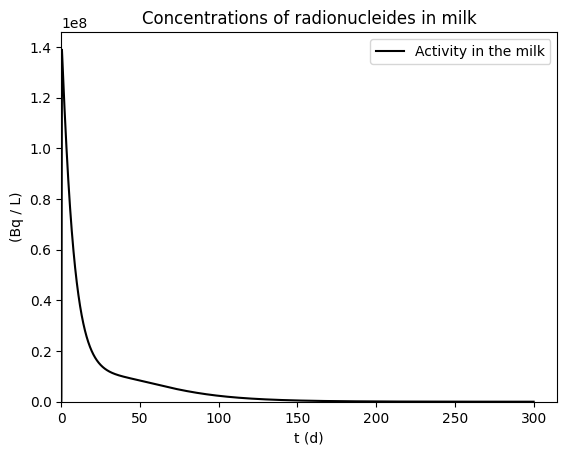

In [91]:
#Plot
plt.plot(t, sum_C_milk, color='black', label = 'Activity in the milk')
plt.title('Concentrations of radionucleides in milk')
plt.xlabel('t (d)')
plt.xlim(left=0)
plt.ylim(bottom = 0)
plt.ylabel('(Bq / L)')
plt.legend(loc = 'upper right')
plt.show()


=== CESIUM EFFECTIVE DOSE (Sv) ===

---- FULL EXPOSURE ----
Adult  : 1.716e+02 Sv
Infant : 6.913e+01 Sv

---- WITH FOOD BAN ----
Adult  : 3.855e+01 Sv
Infant : 1.320e+01 Sv

---- NO AIR EXPOSURE ----
Adult  : 1.715e+02 Sv
Infant : 6.912e+01 Sv

---- NO AIR EXPOSURE + FOOD BAN ----
Adult  : 3.852e+01 Sv
Infant : 1.320e+01 Sv
=== IODINE-131 EFFECTIVE DOSE (Sv) ===

---- FULL EXPOSURE ----
Adult  : 2.027e+01 Sv
Infant : 1.914e+02 Sv

---- WITH FOOD BAN ----
Adult  : 9.090e-01 Sv
Infant : 1.325e+00 Sv

---- NO AIR EXPOSURE ----
Adult  : 1.945e+01 Sv
Infant : 1.901e+02 Sv

---- NO AIR EXPOSURE + FOOD BAN ----
Adult  : 9.499e-02 Sv
Infant : 6.333e-02 Sv

=== TOTAL EFFECTIVE DOSE (Cs + I) ===

---- FULL EXPOSURE ----
Adult  : 1.918e+02 Sv
Infant : 2.605e+02 Sv

---- WITH FOOD BAN ----
Adult  : 3.946e+01 Sv
Infant : 1.453e+01 Sv

---- NO AIR EXPOSURE ----
Adult  : 1.910e+02 Sv
Infant : 2.592e+02 Sv

---- NO AIR EXPOSURE + FOOD BAN ----
Adult  : 3.862e+01 Sv
Infant : 1.326e+01 Sv


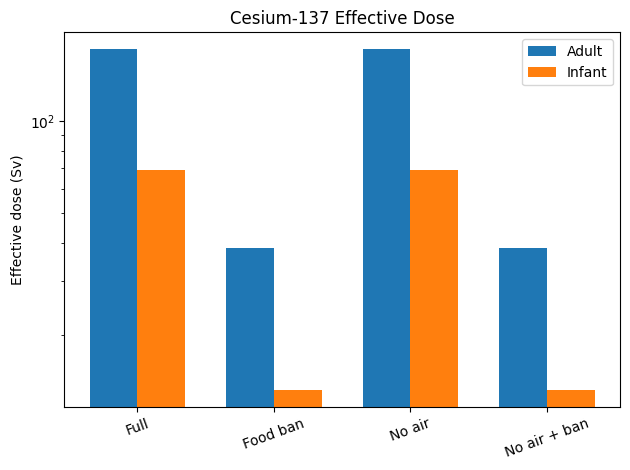

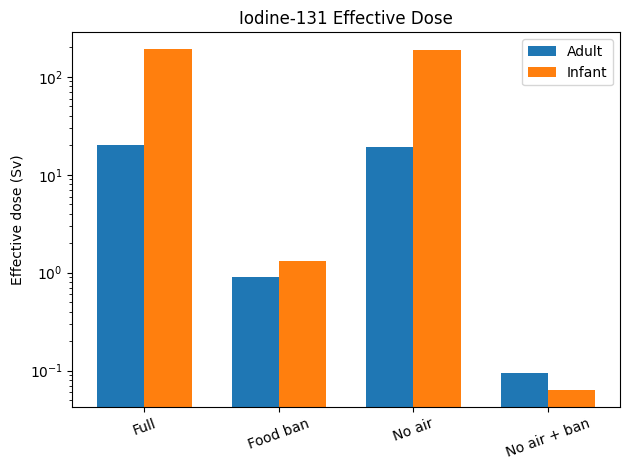

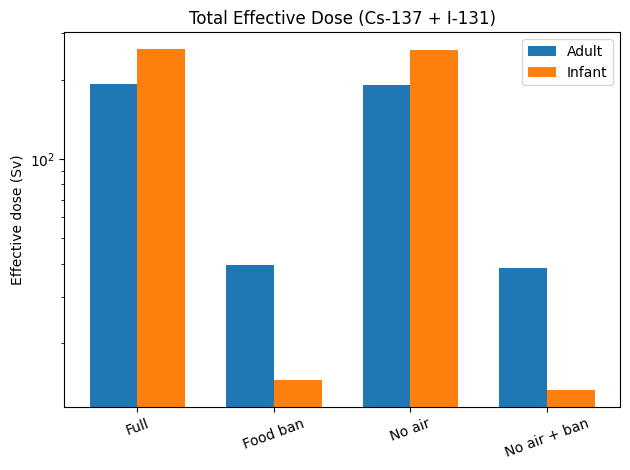

In [59]:
'''



==========================================================================================================================================


==========================================================================================================================================


============== DOSE ESTIMATION ============================================================================================================


==========================================================================================================================================


===========================================================================================================================================




















Parameters needed from the previous section:





# Activity Concentrations that we have computed for Cesium 137:


C_air_cs  #Concentration in the air (Bq/m^3) 


X3_cs  #Concentration at the surface soil (Bq/dry-m²)


X5_cs  #Concentration in the fix soil (Bq/dry-m²)


C_rice_from_harvest #Concentration in rice at harvest (Bq / wet-kg)


C_ordinary_from_harvest #Concentration in ordinary food at harvest (Bq / wet-kg)


C_milk_cs #Concentration in milk (Bq / L)


C_meat_cs #Concentration in meat (Bq / kg)





# Activity Concentrations that we have computed for Iodine 131:


C_air_i  #Concentration in the air (Bq/m^3)


X3_i  #Concentration at the surface soil (Bq/dry-m²)


X5_i  #Concentration in the fix soil (Bq/dry-m²)


# Note: Iodine 131 is not accumulated in food products as milk or meat in this model


'''





# ================= Modify this variable ========================


# Food ban duration is the only variable that we can modify, the rest are constants from the tables of SRS19


# Food ban durations (in hours)


ban_duration_milk = 3984  # hours


ban_duration_meat = 6000  # hours








# =============== DOSE FACTORS ================


# Cesium 137


Cs_DF_air = 8.7e-7


Cs_DF_skin = 1.4e-6


Cs_DF_ground = 1.8e-8





# Iodine 131


I_DF_air =  5.8e-7


I_DF_skin = 9.4e-7


I_DF_ground = 1.2e-8





# --- Internal Exposure: Ingestion (Sv/Bq) ---


# [Infant, Adult]


Cs_DF_ingestion = {"infant": 1.2e-8, "adult": 1.3e-8}


I_DF_ingestion = {"infant": 1.8e-7, "adult": 2.2e-8}





# --- Internal Exposure: Inhalation (Sv/Bq) ---


# [Infant, Adult]


# Note: I-131 is Type F (Fast absorption)


Cs_DF_inhalation = {"infant": 5.4e-9, "adult": 4.6e-9}


I_DF_inhalation = {"infant": 7.2e-8, "adult": 7.4e-9}





# ============== Occupational Fraction (Of) ===========





# Occupational Fraction (Of) for Adults


of_adult_surface_air_deposition = 1.0


of_adult_working_sediments = 0.18


of_adult_submersion_air = 1.0


of_adult_garden_irrigation = 0.06





# Occupational Fraction (Of) for Infants (1 a)


of_infant_surface_air_deposition = 1.0


of_infant_playing_sediments = 0.12


of_infant_submersion_air = 1.0


of_infant_garden_irrigation = 0.06





# =============== Ingestion Rates ================





# Ingestion Rates for Adults


ingestion_adult_plant_foods_kg_a = 410  # Fruit, vegetables, and grain


ingestion_adult_milk_L_a = 250


ingestion_adult_meat_kg_a = 100





# Ingestion Rates for Children


ingestion_child_plant_foods_kg_a = 150


ingestion_child_milk_L_a = 300


ingestion_child_meat_kg_a = 40





# Convert annual ingestion rates to hourly rates


ingestion_adult_plant_kg_h = ingestion_adult_plant_foods_kg_a / 8760


ingestion_adult_milk_L_h   = ingestion_adult_milk_L_a / 8760


ingestion_adult_meat_kg_h  = ingestion_adult_meat_kg_a / 8760





ingestion_child_plant_kg_h = ingestion_child_plant_foods_kg_a / 8760


ingestion_child_milk_L_h   = ingestion_child_milk_L_a / 8760


ingestion_child_meat_kg_h  = ingestion_child_meat_kg_a / 8760








# Breathing rate


breathing_rate_adult = 8760/8760


breathing_rate_child = 1400/8760











#====================================================


#============== EFFECTIVE DOSE CALCULATION ==========


#====================================================








# ---------------- Time handling ----------------


dt_years = 1 / 8760  # 1 hour time step in years





# ---------------- Ground attenuation ----------------


def effective_ground_activity_concentration(X3, X5):


    buildup_factor = 1.17


    attenuation_factor = 0.52


    return X3 + buildup_factor * attenuation_factor * X5





A_ground_cs = effective_ground_activity_concentration(X3_cs, X5_cs)





# ---------------- AIR SUBMERSION (external) ----------------


E_air_cs_adult = (


    np.sum(C_air_cs) * Cs_DF_air * of_adult_submersion_air * dt_years


)





E_air_cs_infant = (


    np.sum(C_air_cs) * Cs_DF_air * of_infant_submersion_air * dt_years


)





# ---------------- GROUND EXPOSURE (external) ----------------


E_ground_cs_adult = (


    np.sum(A_ground_cs) * Cs_DF_ground * of_adult_working_sediments * dt_years


)





E_ground_cs_infant = (


    np.sum(A_ground_cs) * Cs_DF_ground * of_infant_playing_sediments * dt_years


)





# ---------------- INHALATION (internal) ----------------


E_inhalation_cs_adult = (


    np.sum(C_air_cs) * Cs_DF_inhalation["adult"] * breathing_rate_adult


)





E_inhalation_cs_infant = (


    np.sum(C_air_cs) * Cs_DF_inhalation["infant"] * breathing_rate_child


)





# ---------------- INGESTION (NO BAN) ----------------


C_rice_mean = np.mean(C_rice_from_harvest)


C_ordinary_mean = np.mean(C_ordinary_from_harvest)


C_milk_mean = np.mean(C_milk_cs)


C_meat_mean = np.mean(C_meat_cs)





E_ingestion_cs_adult = (


    (C_rice_mean + C_ordinary_mean)


    * Cs_DF_ingestion["adult"]


    * ingestion_adult_plant_foods_kg_a


    +


    C_milk_mean


    * Cs_DF_ingestion["adult"]


    * ingestion_adult_milk_L_a


    +


    C_meat_mean


    * Cs_DF_ingestion["adult"]


    * ingestion_adult_meat_kg_a


)





E_ingestion_cs_infant = (


    (C_rice_mean + C_ordinary_mean)


    * Cs_DF_ingestion["infant"]


    * ingestion_child_plant_foods_kg_a


    +


    C_milk_mean


    * Cs_DF_ingestion["infant"]


    * ingestion_child_milk_L_a


    +


    C_meat_mean


    * Cs_DF_ingestion["infant"]


    * ingestion_child_meat_kg_a


)





# ===================================================


# =============== INGESTION WITH BAN ================


# ===================================================





# Remaining time fraction after ban


remaining_time_fraction_milk = (8760 - ban_duration_milk) / 8760


remaining_time_fraction_meat = (8760 - ban_duration_meat) / 8760





# Milk & meat after ban


C_milk_after_ban = C_milk_cs[ban_duration_milk:]


C_meat_after_ban = C_meat_cs[ban_duration_meat:]





C_milk_effective_mean = np.mean(C_milk_after_ban)


C_meat_effective_mean = np.mean(C_meat_after_ban)





# Rice & ordinary food at harvest


C_rice_harvest_value = C_rice_from_harvest[0]


C_ordinary_harvest_value = C_ordinary_from_harvest[0]





# --- Adult ingestion with ban ---


E_ingestion_cs_adult_with_ban = (


    (C_rice_harvest_value + C_ordinary_harvest_value)


    * Cs_DF_ingestion["adult"]


    * ingestion_adult_plant_foods_kg_a


    +


    C_milk_effective_mean


    * Cs_DF_ingestion["adult"]


    * ingestion_adult_milk_L_a


    * remaining_time_fraction_milk


    +


    C_meat_effective_mean


    * Cs_DF_ingestion["adult"]


    * ingestion_adult_meat_kg_a


    * remaining_time_fraction_meat


)





# --- Infant ingestion with ban ---


E_ingestion_cs_infant_with_ban = (


    (C_rice_harvest_value + C_ordinary_harvest_value)


    * Cs_DF_ingestion["infant"]


    * ingestion_child_plant_foods_kg_a


    +


    C_milk_effective_mean


    * Cs_DF_ingestion["infant"]


    * ingestion_child_milk_L_a


    * remaining_time_fraction_milk


    +


    C_meat_effective_mean


    * Cs_DF_ingestion["infant"]


    * ingestion_child_meat_kg_a


    * remaining_time_fraction_meat


)





# ===================================================


# =============== TOTAL DOSES =======================


# ===================================================





# --- Full (no ban) ---


E_total_cs_adult = (


    E_air_cs_adult


    + E_ground_cs_adult


    + E_inhalation_cs_adult


    + E_ingestion_cs_adult


)





E_total_cs_infant = (


    E_air_cs_infant


    + E_ground_cs_infant


    + E_inhalation_cs_infant


    + E_ingestion_cs_infant


)





# --- With food ban ---


E_total_cs_adult_with_ban = (


    E_air_cs_adult


    + E_ground_cs_adult


    + E_inhalation_cs_adult


    + E_ingestion_cs_adult_with_ban


)





E_total_cs_infant_with_ban = (


    E_air_cs_infant


    + E_ground_cs_infant


    + E_inhalation_cs_infant


    + E_ingestion_cs_infant_with_ban


)





# --- NO AIR submersion ---


E_total_cs_adult_no_air = (


    E_ground_cs_adult


    + E_ingestion_cs_adult


)





E_total_cs_infant_no_air = (


    E_ground_cs_infant


    + E_ingestion_cs_infant


)





# --- NO AIR + food ban ---


E_total_cs_adult_no_air_with_ban = (


    E_ground_cs_adult


    + E_ingestion_cs_adult_with_ban


)





E_total_cs_infant_no_air_with_ban = (


    E_ground_cs_infant


    + E_ingestion_cs_infant_with_ban


)











#====================================================


#============== IODINE-131 DOSE =====================


#====================================================





# ---------------- Ground attenuation ----------------


A_ground_i = effective_ground_activity_concentration(X3_i, X5_i)





# ---------------- AIR SUBMERSION (external) ----------------


E_air_i_adult = (


    np.sum(C_air_i) * I_DF_air * of_adult_submersion_air * dt_years


)





E_air_i_infant = (


    np.sum(C_air_i) * I_DF_air * of_infant_submersion_air * dt_years


)





# ---------------- GROUND EXPOSURE (external) ----------------


E_ground_i_adult = (


    np.sum(A_ground_i) * I_DF_ground * of_adult_working_sediments * dt_years


)





E_ground_i_infant = (


    np.sum(A_ground_i) * I_DF_ground * of_infant_playing_sediments * dt_years


)





# ---------------- INHALATION (internal) ----------------


E_inhalation_i_adult = (


    np.sum(C_air_i) * I_DF_inhalation["adult"] * breathing_rate_adult


)





E_inhalation_i_infant = (


    np.sum(C_air_i) * I_DF_inhalation["infant"] * breathing_rate_child


)





# ---------------- INGESTION ----------------


C_milk_iode_mean = np.mean(C_milk_iode)


C_meat_iode_mean = np.mean(C_meat_iode)





E_ingestion_i_adult = (


    (0 + 0) + # Harvest assumed zero


    C_milk_iode_mean * I_DF_ingestion["adult"] * ingestion_adult_milk_L_a +


    C_meat_iode_mean * I_DF_ingestion["adult"] * ingestion_adult_meat_kg_a


)





E_ingestion_i_infant = (


    (0 + 0) + # Harvest assumed zero


    C_milk_iode_mean * I_DF_ingestion["infant"] * ingestion_child_milk_L_a +


    C_meat_iode_mean * I_DF_ingestion["infant"] * ingestion_child_meat_kg_a


)





# 5. Ingestion (WITH BAN)


# Fixed variable names


C_milk_iode_ban_mean = np.mean(C_milk_iode[ban_duration_milk:])


C_meat_iode_ban_mean = np.mean(C_meat_iode[ban_duration_meat:])





E_ingestion_i_adult_ban = (


    (0 + 0) +


    C_milk_iode_ban_mean * I_DF_ingestion["adult"] * ingestion_adult_milk_L_a * remaining_time_fraction_milk +


    C_meat_iode_ban_mean * I_DF_ingestion["adult"] * ingestion_adult_meat_kg_a * remaining_time_fraction_meat


)





E_ingestion_i_infant_ban = (


    (0 + 0) +


    C_milk_iode_ban_mean * I_DF_ingestion["infant"] * ingestion_child_milk_L_a * remaining_time_fraction_milk +


    C_meat_iode_ban_mean * I_DF_ingestion["infant"] * ingestion_child_meat_kg_a * remaining_time_fraction_meat


)





# ===================================================


# =============== TOTAL I-131 DOSES =================


# ===================================================





# --- Full exposure ---


E_total_i_adult = (


    E_air_i_adult


    + E_ground_i_adult


    + E_inhalation_i_adult


    + E_ingestion_i_adult


)





E_total_i_infant = (


    E_air_i_infant


    + E_ground_i_infant


    + E_inhalation_i_infant


    + E_ingestion_i_infant


)





# --- With food ban (same as full for I-131) ---


E_total_i_adult_with_ban = (


    E_air_i_adult


    + E_ground_i_adult


    + E_inhalation_i_adult


    + E_ingestion_i_adult_ban


)


E_total_i_infant_with_ban = (


    E_air_i_infant


    + E_ground_i_infant


    + E_inhalation_i_infant


    + E_ingestion_i_infant_ban


)





# --- NO AIR submersion ---


E_total_i_adult_no_air = (


    E_ground_i_adult 


    + E_ingestion_i_adult


)





E_total_i_infant_no_air = (


    E_ground_i_infant 


    + E_ingestion_i_infant


)





# --- NO AIR + food ban ---


E_total_i_adult_no_air_with_ban = (


    E_ground_i_adult


    + E_ingestion_i_adult_ban


)


E_total_i_infant_no_air_with_ban = (


    E_ground_i_infant


    + E_ingestion_i_infant_ban


)





#====================================================


#============== TOTAL (CS + I) ======================


#====================================================





E_total_all_adult = E_total_cs_adult + E_total_i_adult


E_total_all_infant = E_total_cs_infant + E_total_i_infant





E_total_all_adult_with_ban = (


    E_total_cs_adult_with_ban + E_total_i_adult_with_ban


)





E_total_all_infant_with_ban = (


    E_total_cs_infant_with_ban + E_total_i_infant_with_ban


)





E_total_all_adult_no_air = (


    E_total_cs_adult_no_air + E_total_i_adult_no_air


)





E_total_all_infant_no_air = (


    E_total_cs_infant_no_air + E_total_i_infant_no_air


)





E_total_all_adult_no_air_with_ban = (


    E_total_cs_adult_no_air_with_ban + E_total_i_adult_no_air_with_ban


)





E_total_all_infant_no_air_with_ban = (


    E_total_cs_infant_no_air_with_ban + E_total_i_infant_no_air_with_ban


)





#====================================================


#============== OUTPUT ==============================


#====================================================





print("====================================")


print("=== CESIUM EFFECTIVE DOSE (Sv) ===")


print("====================================\n")





print("---- FULL EXPOSURE ----")


print(f"Adult  : {E_total_cs_adult:.3e} Sv")


print(f"Infant : {E_total_cs_infant:.3e} Sv\n")





print("---- WITH FOOD BAN ----")


print(f"Adult  : {E_total_cs_adult_with_ban:.3e} Sv")


print(f"Infant : {E_total_cs_infant_with_ban:.3e} Sv\n")





print("---- NO AIR EXPOSURE ----")


print(f"Adult  : {E_total_cs_adult_no_air:.3e} Sv")


print(f"Infant : {E_total_cs_infant_no_air:.3e} Sv\n")





print("---- NO AIR EXPOSURE + FOOD BAN ----")


print(f"Adult  : {E_total_cs_adult_no_air_with_ban:.3e} Sv")


print(f"Infant : {E_total_cs_infant_no_air_with_ban:.3e} Sv")





print("====================================")


print("=== IODINE-131 EFFECTIVE DOSE (Sv) ===")


print("====================================\n")





print("---- FULL EXPOSURE ----")


print(f"Adult  : {E_total_i_adult:.3e} Sv")


print(f"Infant : {E_total_i_infant:.3e} Sv\n")





print("---- WITH FOOD BAN ----")


print(f"Adult  : {E_total_i_adult_with_ban:.3e} Sv")


print(f"Infant : {E_total_i_infant_with_ban:.3e} Sv\n")





print("---- NO AIR EXPOSURE ----")


print(f"Adult  : {E_total_i_adult_no_air:.3e} Sv")


print(f"Infant : {E_total_i_infant_no_air:.3e} Sv\n")





print("---- NO AIR EXPOSURE + FOOD BAN ----")


print(f"Adult  : {E_total_i_adult_no_air_with_ban:.3e} Sv")


print(f"Infant : {E_total_i_infant_no_air_with_ban:.3e} Sv\n")








print("====================================")


print("=== TOTAL EFFECTIVE DOSE (Cs + I) ===")


print("====================================\n")





print("---- FULL EXPOSURE ----")


print(f"Adult  : {E_total_all_adult:.3e} Sv")


print(f"Infant : {E_total_all_infant:.3e} Sv\n")





print("---- WITH FOOD BAN ----")


print(f"Adult  : {E_total_all_adult_with_ban:.3e} Sv")


print(f"Infant : {E_total_all_infant_with_ban:.3e} Sv\n")





print("---- NO AIR EXPOSURE ----")


print(f"Adult  : {E_total_all_adult_no_air:.3e} Sv")


print(f"Infant : {E_total_all_infant_no_air:.3e} Sv\n")





print("---- NO AIR EXPOSURE + FOOD BAN ----")


print(f"Adult  : {E_total_all_adult_no_air_with_ban:.3e} Sv")


print(f"Infant : {E_total_all_infant_no_air_with_ban:.3e} Sv")








#====================================================


#============== PLOTTING RESULTS ====================


#====================================================





scenarios = [


    "Full",


    "Food ban",


    "No air",


    "No air + ban",


]





scenarios_i = [


    "Full",


    "No air",


]





x = np.arange(len(scenarios))


x_i = np.arange(len(scenarios_i))


width = 0.35





# ================= CESIUM =================


cs_adult = [


    E_total_cs_adult,


    E_total_cs_adult_with_ban,


    E_total_cs_adult_no_air,


    E_total_cs_adult_no_air_with_ban,


]





cs_infant = [


    E_total_cs_infant,


    E_total_cs_infant_with_ban,


    E_total_cs_infant_no_air,


    E_total_cs_infant_no_air_with_ban,


]





plt.figure()


plt.bar(x - width/2, cs_adult, width, label="Adult")


plt.bar(x + width/2, cs_infant, width, label="Infant")


plt.xticks(x, scenarios, rotation=20)


plt.ylabel("Effective dose (Sv)")


plt.title("Cesium-137 Effective Dose")


plt.yscale("log")


plt.legend()


plt.tight_layout()


plt.show()





# ================= IODINE =================


i_adult = [


    E_total_i_adult,


    E_total_i_adult_with_ban,


    E_total_i_adult_no_air,


    E_total_i_adult_no_air_with_ban,





]





i_infant = [


    E_total_i_infant,


    E_total_i_infant_with_ban,


    E_total_i_infant_no_air,


    E_total_i_infant_no_air_with_ban,


]





plt.figure()


plt.bar(x - width/2, i_adult, width, label="Adult")


plt.bar(x + width/2, i_infant, width, label="Infant")


plt.xticks(x, scenarios, rotation=20)


plt.ylabel("Effective dose (Sv)")


plt.title("Iodine-131 Effective Dose")


plt.yscale("log")


plt.legend()


plt.tight_layout()


plt.show()





# ================= TOTAL =================


tot_adult = [


    E_total_all_adult,


    E_total_all_adult_with_ban,


    E_total_all_adult_no_air,


    E_total_all_adult_no_air_with_ban,


]





tot_infant = [


    E_total_all_infant,


    E_total_all_infant_with_ban,


    E_total_all_infant_no_air,


    E_total_all_infant_no_air_with_ban,


]





plt.figure()


plt.bar(x - width/2, tot_adult, width, label="Adult")


plt.bar(x + width/2, tot_infant, width, label="Infant")


plt.xticks(x, scenarios, rotation=20)


plt.ylabel("Effective dose (Sv)")


plt.title("Total Effective Dose (Cs-137 + I-131)")


plt.yscale("log")


plt.legend()


plt.tight_layout()


plt.show()